# Demand Forecasting for Multiple Store-Item Time Series

Narrative walkthrough of the pipeline in `src/`. This notebook re-uses the exact same
`src/features.py`, `src/train.py`-style logic so results match the scripted pipeline; it's
meant as a readable companion to the scripts, not a replacement for them.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_raw_data, smape
from features import build_pivot, compute_feature_frame, attach_target, FEATURE_COLUMNS, CATEGORICAL_COLUMNS

train, test, sample_sub = load_raw_data('../data')
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 1. Quick look at the data

In [2]:
print('Train date range:', train.date.min().date(), '->', train.date.max().date())
print('Test date range :', test.date.min().date(), '->', test.date.max().date())
print('Stores:', train.store.nunique(), '| Items:', train.item.nunique(),
      '| Series:', train.groupby(['store','item']).ngroups)
train.sales.describe()

Train date range: 2013-01-01 -> 2017-12-31
Test date range : 2018-01-01 -> 2018-03-31
Stores: 10 | Items: 50 | Series: 500


count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

## 2. Seasonality at a glance

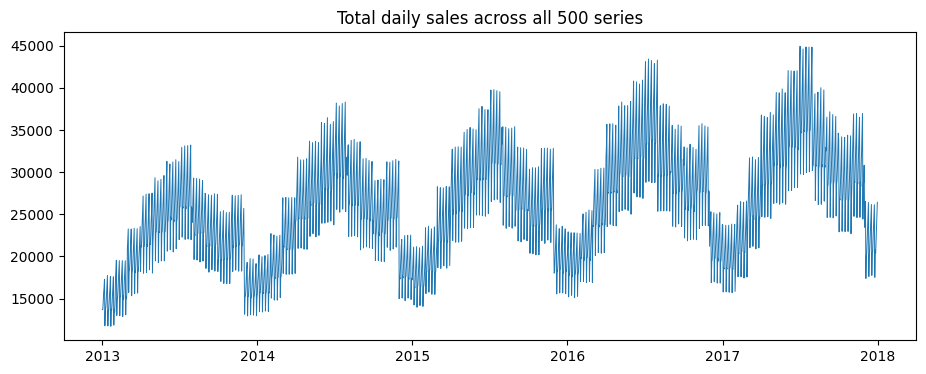

In [3]:
daily = train.groupby('date')['sales'].sum()
plt.figure(figsize=(11,4))
plt.plot(daily.index, daily.values, linewidth=0.7)
plt.title('Total daily sales across all 500 series')
plt.show()

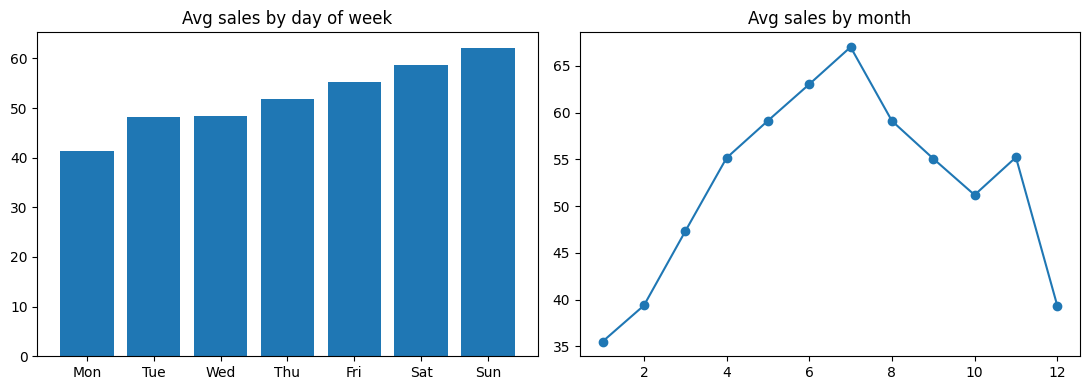

In [4]:
dow = train.assign(dayofweek=train.date.dt.dayofweek).groupby('dayofweek')['sales'].mean()
mon = train.assign(month=train.date.dt.month).groupby('month')['sales'].mean()

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values)
ax[0].set_title('Avg sales by day of week')
ax[1].plot(mon.index, mon.values, marker='o')
ax[1].set_title('Avg sales by month')
plt.tight_layout()
plt.show()

## 3. Feature engineering

See `src/features.py` for the full, vectorised implementation. Here we build the pivot table
and compute a small sample of features to inspect.

In [5]:
full_range = pd.date_range(train.date.min(), test.date.max(), freq='D')
pivot = build_pivot(train, full_range)
print(pivot.shape)
pivot.iloc[-5:, :5]

(1916, 500)


store,1,2,3,4,5
item,1,1,1,1,1
date,,,,,
2018-03-27,NaN,NaN,NaN,NaN,NaN
2018-03-28,NaN,NaN,NaN,NaN,NaN
2018-03-29,NaN,NaN,NaN,NaN,NaN
2018-03-30,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN


In [6]:
sample_dates = pd.date_range('2017-12-01', '2017-12-05')
feat_sample = compute_feature_frame(pivot, sample_dates)
feat_sample = attach_target(feat_sample, train)
feat_sample[['date','store','item','sales','lag_7','lag_364','roll_mean_7','roll_mean_28','dayofweek']].head(10)

,date,store,item,sales,lag_7,lag_364,roll_mean_7,roll_mean_28,dayofweek
0,2017-12-01,1,1,19,22.0,11.0,20.285714,22.535714,4
1,2017-12-01,2,1,31,38.0,17.0,32.571429,33.107143,4
2,2017-12-01,3,1,19,31.0,15.0,28.571429,29.464286,4
3,2017-12-01,4,1,17,33.0,18.0,27.142857,27.000000,4
4,2017-12-01,5,1,9,24.0,19.0,20.714286,19.892857,4
5,2017-12-01,6,1,11,23.0,27.0,18.714286,19.464286,4
6,2017-12-01,7,1,15,18.0,13.0,19.428571,17.678571,4
7,2017-12-01,8,1,28,40.0,26.0,30.857143,32.285714,4
8,2017-12-01,9,1,19,34.0,20.0,27.714286,26.500000,4
9,2017-12-01,10,1,22,31.0,21.0,29.000000,28.642857,4


## 4. Model training & validation

The full training run (with early stopping against a Jan-Mar 2017 validation fold) lives in
`src/train.py` — run `python src/train.py` from the project root to reproduce
`models/lgbm_model.txt` and `reports/model_report.md`. The report is loaded below.

In [7]:
report_path = '../reports/model_report.md'
if os.path.exists(report_path):
    print(open(report_path).read())
else:
    print('Run `python src/train.py` from the project root first.')

# Model training report

- Training rows: 548,000
- Validation window: 2017-01-01 to 2017-03-31 (45,000 rows)
- Best boosting iteration (early stopping): **956**
- Validation SMAPE: **13.5027**

## Top features by gain

| feature       |        gain |
|:--------------|------------:|
| lag_364       | 1.54366e+09 |
| roll_mean_7   | 1.1882e+09  |
| roll_mean_14  | 4.42264e+08 |
| lag_7         | 2.53196e+08 |
| dayofweek     | 6.05447e+07 |
| roll_mean_28  | 5.94782e+07 |
| lag_14        | 5.09632e+07 |
| lag_21        | 2.01416e+07 |
| lag_35        | 1.44039e+07 |
| lag_28        | 1.40115e+07 |
| day           | 9.93063e+06 |
| roll_mean_365 | 9.34378e+06 |
| month         | 9.32333e+06 |
| item          | 9.00955e+06 |
| month_sin     | 5.97547e+06 |
| trend_ratio   | 5.96331e+06 |
| dayofyear     | 4.88084e+06 |
| dow_cos       | 3.92247e+06 |
| roll_mean_90  | 3.85404e+06 |
| month_cos     | 3.85051e+06 |

![feature importance](figures/feature_importance.png)



## 5. Recursive 90-day forecast & submission

`src/predict.py` retrains on the full 2013-2017 history and walks forward one day at a time
over the Jan-Mar 2018 test horizon (each day's lag/rolling features depend on predictions made
for earlier days in the same horizon). The resulting submission is loaded below.

In [8]:
sub_path = '../outputs/submission.csv'
if os.path.exists(sub_path):
    submission = pd.read_csv(sub_path)
    display(submission.head())
    submission.sales.describe()
else:
    print('Run `python src/predict.py` from the project root first.')

,id,sales
0,0,13
1,1,14
2,2,15
3,3,15
4,4,16


## 6. Takeaways

- A single global LightGBM model, fed lag/rolling/calendar features derived from a wide
  pivot table, forecasts all 500 series jointly and scales cleanly to more series.
- Validating on the same seasonal window as the real test period (Jan-Mar) gives a much more
  trustworthy estimate of forecast error than a random split.
- Recursive (walk-forward) prediction is required whenever short lags (e.g. 7 days) are used
  and the forecast horizon (90 days) is longer than that lag.
